# Model 01 - NBA Player Segmentation
**Discipline:** Marketing DS  
**Question:** Do traditional basketball positions actually capture how players play, or are there natural statistical archetypes that tell a different story?  
**Method:** K-Means clustering + UMAP dimensionality reduction  
**LinkedIn Hook:** I clustered every NBA player by stats. The results completely broke traditional positions.

## 0. Imports & Setup

In [120]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, pairwise_distances
import umap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
OUTPUTS_DIR = 'outputs/'
print('All imports successful.')

All imports successful.


## 1. Data Collection
Pull 3 seasons of NBA advanced stats via `nba_api`. Filter to players with >= 500 minutes played.

In [121]:
from nba_api.stats.endpoints import leaguedashplayerstats

SEASONS = ['2002-03', '2003-04', '2004-05']
MIN_MINUTES = 15  # Min per game min

frames = []
for season in SEASONS:
    print(f'Fetching {season}...', end=' ')
    time.sleep(1)  # nba_api rate limit
    resp = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        per_mode_detailed='Totals',
        measure_type_detailed_defense='Advanced'
    )
    df = resp.get_data_frames()[0]
    df['SEASON'] = season
    frames.append(df)
    print(f'{len(df)} players')

raw = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows across 3 seasons: {len(raw)}')
raw.head(3)

Fetching 2002-03... 428 players
Fetching 2003-04... 442 players
Fetching 2004-05... 464 players

Total rows across 3 seasons: 1334


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,...,NET_RATING_RANK,sp_work_NET_RATING_RANK,AST_PCT_RANK,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,E_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,USG_PCT_RANK,E_USG_PCT_RANK,E_PACE_RANK,PACE_RANK,sp_work_PACE_RANK,PIE_RANK,FGM_RANK,FGA_RANK,FGM_PG_RANK,FGA_PG_RANK,FG_PCT_RANK,TEAM_COUNT,SEASON
0,2062,A.J. Guyton,A.J.,1610612744,GSW,25.000,2,1,1,0.500,4.300,94.900,87.500,87.500,98.800,100.000,100.000,-3.900,-12.500,-12.500,0.400,2.000,28.600,0.000,0.000,...,410,410,7,97,43,410,416,414,324,325,420,421,28,14,423,395,395,422,420,416,420,373,420,1,2002-03
1,243,Aaron McKie,Aaron,1610612755,PHI,30.000,80,47,33,0.588,29.700,102.400,102.500,102.500,98.400,97.700,97.700,4.000,4.700,4.700,0.185,2.550,25.000,0.026,0.128,...,75,75,109,42,72,300,178,237,103,105,218,235,308,302,171,166,166,120,110,104,130,120,209,1,2002-03
2,1425,Aaron Williams,Aaron,1610612751,NJN,31.000,81,49,32,0.605,19.800,97.700,98.100,98.100,96.800,96.200,96.200,0.900,1.900,1.900,0.092,1.040,13.200,0.087,0.119,...,146,146,256,249,232,80,206,143,261,256,232,211,274,283,234,250,250,263,169,178,206,211,132,1,2002-03


## 2. Preprocessing
- Filter by minimum minutes  
- Select clustering features  
- Keep most recent season per player (dedup)  
- StandardScaler

In [122]:
df = raw[raw['MIN'] >= MIN_MINUTES].copy()
print(f'Players with >= {MIN_MINUTES} min: {len(df)}')

FEATURES = [
    'USG_PCT',   # Usage rate
    'AST_PCT',   # Assist %
    'REB_PCT',   # Rebound %
    'OREB_PCT',  # Offensive rebound %
    'DREB_PCT',  # Defensive rebound %
    'STL_PCT',   # Steal %
    'BLK_PCT',   # Block %
    'TS_PCT',    # True shooting %
    'E_TOV_PCT', # Turnover %
    'PACE',      # Team pace proxy
]

available = [f for f in FEATURES if f in df.columns]
missing   = [f for f in FEATURES if f not in df.columns]
if missing:
    print(f'Missing (will skip): {missing}')
FEATURES = available

# Most recent season per player
df = df.sort_values('SEASON', ascending=False)
df = df.drop_duplicates(subset='PLAYER_NAME', keep='first').reset_index(drop=True)
print(f'Unique players: {len(df)}')

df_clean = df.dropna(subset=FEATURES).copy()
print(f'After dropping nulls: {len(df_clean)}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURES])
print(f'Features used: {FEATURES}')

Players with >= 15 min: 859
Missing (will skip): ['STL_PCT', 'BLK_PCT']
Unique players: 404
After dropping nulls: 404
Features used: ['USG_PCT', 'AST_PCT', 'REB_PCT', 'OREB_PCT', 'DREB_PCT', 'TS_PCT', 'E_TOV_PCT', 'PACE']


## 3. Dimensionality Reduction - UMAP + PCA

In [123]:
reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
X_umap  = reducer.fit_transform(X_scaled)
df_clean = df_clean.copy()
df_clean['UMAP_1'] = X_umap[:, 0]
df_clean['UMAP_2'] = X_umap[:, 1]

pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df_clean['PCA_1'] = X_pca[:, 0]
df_clean['PCA_2'] = X_pca[:, 1]

print(f'PCA variance explained (2 components): {pca.explained_variance_ratio_.cumsum()[1]:.1%}')

PCA variance explained (2 components): 59.4%


## 4. Clustering - Choosing K
K-Means for K=4..10. Elbow curve + silhouette scores.

K=4: inertia=1792.0, silhouette=0.156
K=5: inertia=1655.8, silhouette=0.157
K=6: inertia=1536.9, silhouette=0.158
K=7: inertia=1455.2, silhouette=0.150
K=8: inertia=1365.3, silhouette=0.153
K=9: inertia=1311.0, silhouette=0.145
K=10: inertia=1263.8, silhouette=0.141


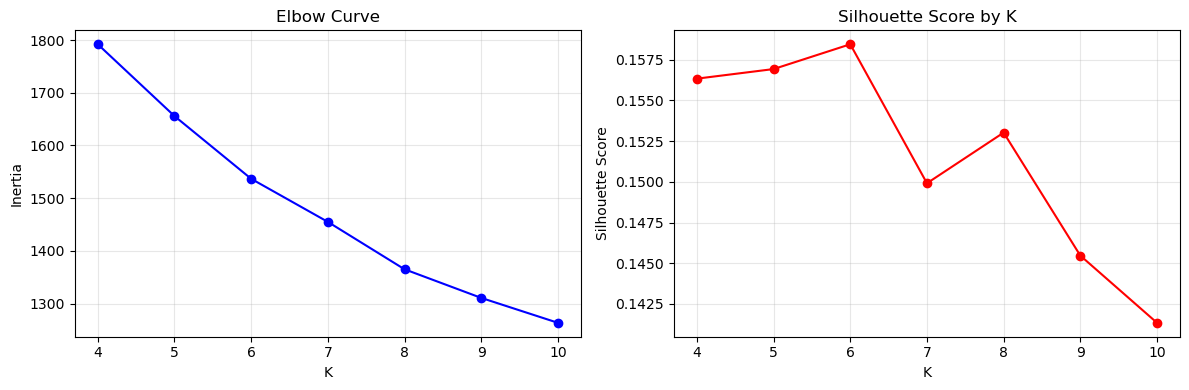

Best K by silhouette: 6


In [124]:
K_RANGE    = range(4, 11)
inertias   = []
silhouettes = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'K={k}: inertia={km.inertia_:.1f}, silhouette={silhouettes[-1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'bo-')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve'); axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, 'ro-')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR + 'elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'Best K by silhouette: {best_k}')

In [125]:
# Adjust K manually here if the elbow suggests a different value
K = best_k  # e.g. K = 7

km_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
df_clean['CLUSTER'] = km_final.fit_predict(X_scaled)

print(f'Final K={K}')
print(df_clean['CLUSTER'].value_counts().sort_index())

Final K=6
CLUSTER
0    75
1    45
2    88
3    91
4    60
5    45
Name: count, dtype: int64


## 5. Analysis - Profile Each Cluster

In [126]:
cluster_profiles = df_clean.groupby('CLUSTER')[FEATURES].mean().round(3)
print('Cluster Profiles (mean stats):')
cluster_profiles

Cluster Profiles (mean stats):


,USG_PCT,AST_PCT,REB_PCT,OREB_PCT,DREB_PCT,TS_PCT,E_TOV_PCT,PACE
CLUSTER,,,,,,,,
0,0.175,0.228,0.052,0.022,0.084,0.460,12.332,92.522
1,0.223,0.110,0.134,0.079,0.188,0.540,10.273,92.690
2,0.178,0.111,0.066,0.031,0.101,0.533,8.856,93.678
3,0.165,0.089,0.104,0.069,0.140,0.507,13.288,93.090
4,0.240,0.255,0.060,0.025,0.096,0.538,10.300,93.848
5,0.149,0.052,0.149,0.108,0.190,0.526,14.371,92.200


In [127]:
# Top 5 players closest to each cluster centroid
centroids = km_final.cluster_centers_
dists     = pairwise_distances(X_scaled, centroids)
df_clean['DIST_TO_CENTROID'] = [dists[i, c] for i, c in enumerate(df_clean['CLUSTER'])]

for c in range(K):
    top5 = (
        df_clean[df_clean['CLUSTER'] == c]
        .nsmallest(5, 'DIST_TO_CENTROID')[['PLAYER_NAME', 'SEASON', 'DIST_TO_CENTROID']]
    )
    print(f'--- Cluster {c} ---')
    print(top5.to_string(index=False))
    print()

--- Cluster 0 ---
      PLAYER_NAME  SEASON  DIST_TO_CENTROID
 Erick Strickland 2004-05             0.617
Vincent Yarbrough 2002-03             0.976
Anfernee Hardaway 2004-05             1.086
     Charlie Ward 2004-05             1.104
     Keith McLeod 2004-05             1.177

--- Cluster 1 ---
  PLAYER_NAME  SEASON  DIST_TO_CENTROID
   Chris Bosh 2004-05             1.032
Kenyon Martin 2004-05             1.164
Carlos Boozer 2004-05             1.174
  Mehmet Okur 2004-05             1.191
  Drew Gooden 2004-05             1.200

--- Cluster 2 ---
    PLAYER_NAME  SEASON  DIST_TO_CENTROID
    Devin Brown 2004-05             0.527
Morris Peterson 2004-05             0.778
   Caron Butler 2004-05             0.999
   Steven Smith 2002-03             1.047
    Eddie Jones 2004-05             1.047

--- Cluster 3 ---
  PLAYER_NAME  SEASON  DIST_TO_CENTROID
 Jason Caffey 2002-03             0.833
Antonio Davis 2004-05             0.849
 Robert Horry 2004-05             0.861
Scott Pad

In [128]:
# ---- EDIT THESE after reviewing the profiles above ----
# Examples: 'Rim Protector', '3&D Wing', 'Pass-First PG', 'Scoring Guard',
#           'Stretch Big', 'Two-Way Wing', 'Offensive Hub'

CLUSTER_LABELS = {i: f'Cluster {i}' for i in range(K)}

# CLUSTER_LABELS = {
#     0: 'Rim Protector',
#     1: '3&D Wing',
#     2: 'Pass-First PG',
#     3: 'Scoring Guard',
#     4: 'Stretch Big',
#     5: 'Two-Way Wing',
#     6: 'Offensive Hub',
# }

df_clean['ARCHETYPE'] = df_clean['CLUSTER'].map(CLUSTER_LABELS)
print('Archetype counts:')
print(df_clean['ARCHETYPE'].value_counts())

Archetype counts:
ARCHETYPE
Cluster 3    91
Cluster 2    88
Cluster 0    75
Cluster 4    60
Cluster 1    45
Cluster 5    45
Name: count, dtype: int64


## 6. Visualizations

In [129]:
# Interactive UMAP scatter (Plotly)
fig = px.scatter(
    df_clean,
    x='UMAP_1', y='UMAP_2',
    color='ARCHETYPE',
    hover_name='PLAYER_NAME',
    hover_data={'SEASON': True, 'UMAP_1': False, 'UMAP_2': False},
    title=f'NBA Player Archetypes - UMAP Projection (K={K})',
    width=900, height=650,
    template='plotly_white'
)
fig.update_traces(marker=dict(size=7, opacity=0.8))
fig.write_html(OUTPUTS_DIR + 'umap_plot.html')
print('Saved: outputs/umap_plot.html')
fig.show()

Saved: outputs/umap_plot.html


In [140]:
RADAR_FEATURES

['USG_PCT', 'AST_PCT', 'REB_PCT', 'TS_PCT']

Saved: outputs/cluster_profiles.png


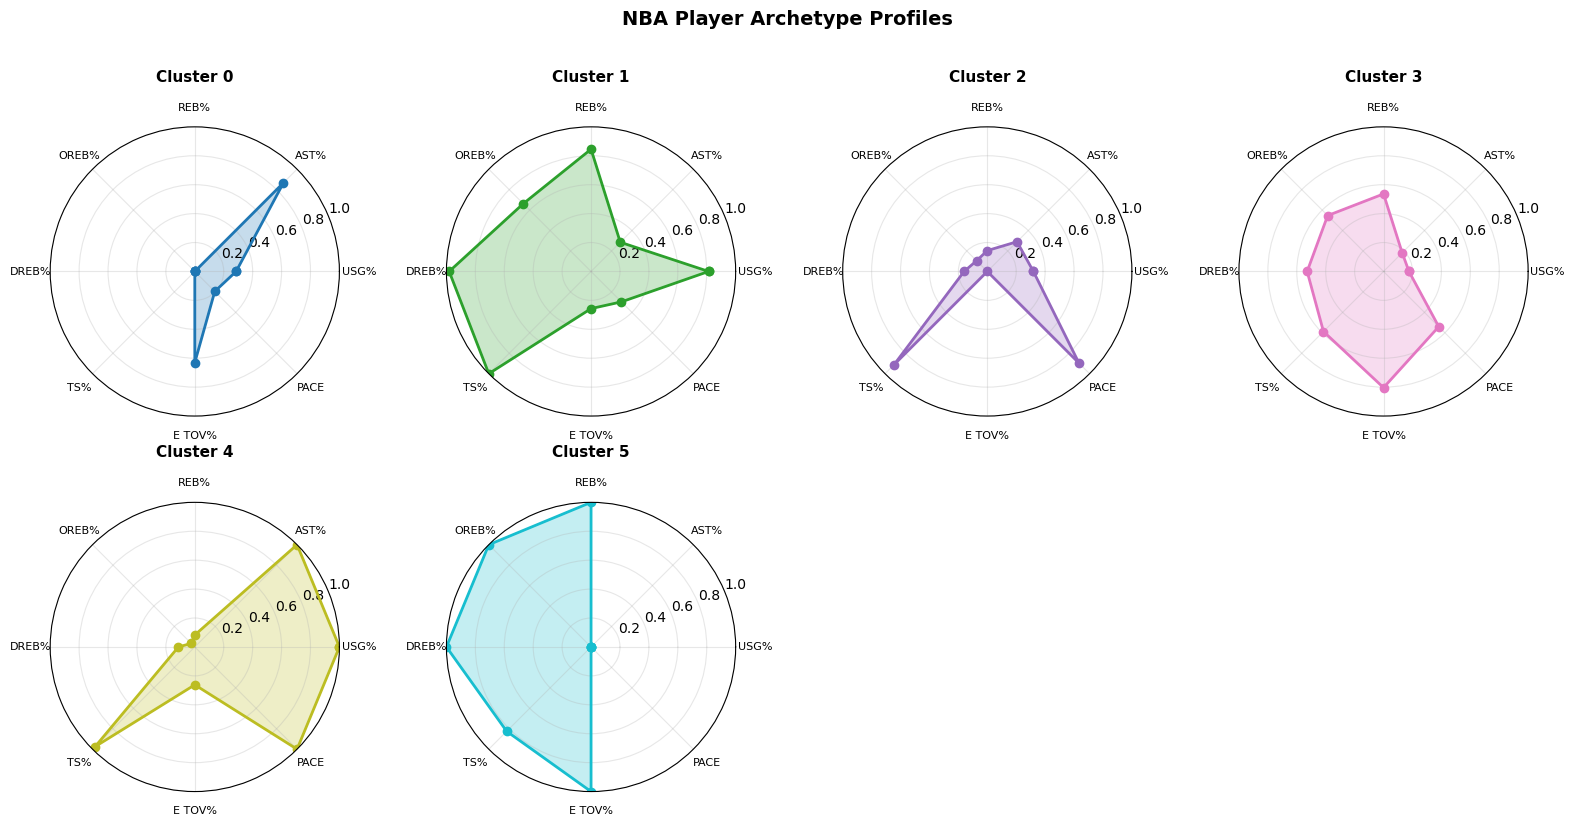

In [141]:
# Radar / Spider charts per cluster
RADAR_FEATURES = [f for f in ['USG_PCT', 'AST_PCT', 'REB_PCT', 'OREB_PCT', 'DREB_PCT', 'TS_PCT', 'E_TOV_PCT', 'PACE'] if f in FEATURES]

profile_norm = cluster_profiles[RADAR_FEATURES].copy()
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

cols = min(4, K)
rows = (K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4), subplot_kw=dict(polar=True))
axes = np.array(axes).flatten()

N      = len(RADAR_FEATURES)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
colors  = plt.cm.tab10(np.linspace(0, 1, K))

for i, (cluster_id, row) in enumerate(profile_norm.iterrows()):
    ax     = axes[i]
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace('_PCT', '%').replace('_', ' ') for f in RADAR_FEATURES], size=8)
    ax.set_ylim(0, 1)
    ax.set_title(CLUSTER_LABELS[cluster_id], size=11, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)

for j in range(K, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('NBA Player Archetype Profiles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR + 'cluster_profiles.png', dpi=150, bbox_inches='tight')
print('Saved: outputs/cluster_profiles.png')
plt.show()

In [131]:
# Top 10 players per cluster
for c in range(K):
    label = CLUSTER_LABELS[c]
    top10 = (
        df_clean[df_clean['CLUSTER'] == c]
        .nsmallest(10, 'DIST_TO_CENTROID')[['PLAYER_NAME', 'SEASON']]
        .reset_index(drop=True)
    )
    top10.index += 1
    print(f'=== {label} ===')
    print(top10.to_string())
    print()

=== Cluster 0 ===
          PLAYER_NAME   SEASON
1    Erick Strickland  2004-05
2   Vincent Yarbrough  2002-03
3   Anfernee Hardaway  2004-05
4        Charlie Ward  2004-05
5        Keith McLeod  2004-05
6      Derek Anderson  2004-05
7        Doug Overton  2003-04
8         Marko Jaric  2004-05
9       Keyon Dooling  2004-05
10      Nick Van Exel  2004-05

=== Cluster 1 ===
        PLAYER_NAME   SEASON
1        Chris Bosh  2004-05
2     Kenyon Martin  2004-05
3     Carlos Boozer  2004-05
4       Mehmet Okur  2004-05
5       Drew Gooden  2004-05
6       Elton Brand  2004-05
7   Arvydas Sabonis  2002-03
8        Lamar Odom  2004-05
9         Ndudi Ebi  2004-05
10     Kenny Thomas  2004-05

=== Cluster 2 ===
        PLAYER_NAME   SEASON
1       Devin Brown  2004-05
2   Morris Peterson  2004-05
3      Caron Butler  2004-05
4      Steven Smith  2002-03
5       Eddie Jones  2004-05
6    Chris Crawford  2003-04
7     Eric Williams  2004-05
8        Tim Thomas  2004-05
9   Jonathan Bender  20

## 7. Outputs

In [132]:
output_cols = ['PLAYER_NAME', 'SEASON', 'CLUSTER', 'ARCHETYPE', 'DIST_TO_CENTROID',
               'UMAP_1', 'UMAP_2'] + FEATURES
output_cols = [c for c in output_cols if c in df_clean.columns]

df_clean[output_cols].to_csv(OUTPUTS_DIR + 'clustered_players.csv', index=False)
print('Saved: outputs/clustered_players.csv')

print('\n--- Final Summary ---')
print(f'Players clustered : {len(df_clean)}')
print(f'Seasons           : {SEASONS}')
print(f'K                 : {K}')
print('\nArchetype distribution:')
print(df_clean.groupby('ARCHETYPE').size().sort_values(ascending=False).to_string())

Saved: outputs/clustered_players.csv

--- Final Summary ---
Players clustered : 404
Seasons           : ['2002-03', '2003-04', '2004-05']
K                 : 6

Archetype distribution:
ARCHETYPE
Cluster 3    91
Cluster 2    88
Cluster 0    75
Cluster 4    60
Cluster 1    45
Cluster 5    45


## 8. Insight Extraction
Answer these before writing the LinkedIn post:

1. **Which famous player ended up in a surprising cluster?**  
2. **Which traditional position is most fractured across clusters?**  
3. **What archetype has no traditional position equivalent?**  
4. **Which cluster has the highest TS% (most efficient scorers)?**  

## 9. Position vs. Cluster, Do Traditional Positions Break Down?
Map `PLAYER_POSITION` back onto the clustered players and see how each traditional position scatters (or concentrates) across archetypes.

In [134]:
from nba_api.stats.endpoints import playerindex

time.sleep(1)
_idx = playerindex.PlayerIndex(historical_nullable=1).get_data_frames()[0]

pos_df = (
    _idx[['PERSON_ID', 'POSITION']]
    .rename(columns={'PERSON_ID': 'PLAYER_ID'})
    .drop_duplicates(subset='PLAYER_ID')
)
pos_df['PLAYER_ID'] = pos_df['PLAYER_ID'].astype('int64')

df_clean = df_clean.drop(columns=['POSITION'], errors='ignore')
df_clean['PLAYER_ID'] = df_clean['PLAYER_ID'].astype('int64')
df_clean = df_clean.merge(pos_df, on='PLAYER_ID', how='left')
df_clean['POSITION'] = df_clean['POSITION'].fillna('Unknown')

print('Position distribution in dataset:')
print(df_clean['POSITION'].value_counts())
print(f"\nUnknown count: {(df_clean['POSITION'] == 'Unknown').sum()}")


Position distribution in dataset:
POSITION
G      131
F      117
C       54
G-F     33
F-C     29
C-F     25
F-G     15
Name: count, dtype: int64

Unknown count: 0


In [135]:
# --- Crosstab: position rows, cluster columns (% of each position) ---
crosstab = pd.crosstab(
    df_clean['POSITION'],
    df_clean['ARCHETYPE'],
    normalize='index'   # each row sums to 1 "where does each position land?"
).round(3)

print('Position Archetype distribution (row %):')
crosstab


Position Archetype distribution (row %):


ARCHETYPE,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
POSITION,,,,,,
C,0.000,0.148,0.019,0.426,0.000,0.407
C-F,0.040,0.400,0.080,0.280,0.000,0.200
F,0.068,0.154,0.239,0.385,0.085,0.068
F-C,0.000,0.276,0.069,0.310,0.000,0.345
F-G,0.267,0.000,0.533,0.000,0.200,0.000
G,0.435,0.000,0.214,0.015,0.336,0.000
G-F,0.152,0.030,0.576,0.152,0.091,0.000


Saved: outputs/position_vs_cluster.png


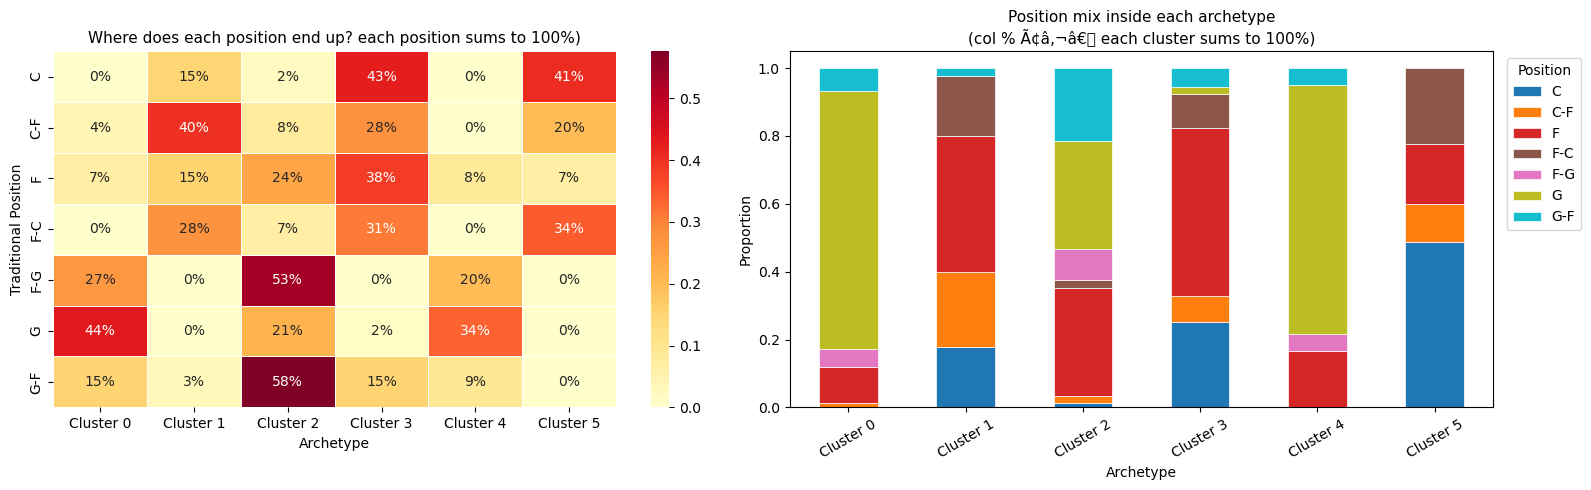

In [ ]:
# --- Heatmap: how spread out is each position across clusters? ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: % of each position per archetype
sns.heatmap(
    crosstab,
    annot=True, fmt='.0%',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Where does each position end up? each position sums to 100%)', fontsize=11)
axes[0].set_xlabel('Archetype')
axes[0].set_ylabel('Traditional Position')

# Right: stacked bar showing position mix inside each archetype
crosstab_arch = pd.crosstab(
    df_clean['ARCHETYPE'],
    df_clean['POSITION'],
    normalize='index'
)
crosstab_arch.plot(
    kind='bar', stacked=True, colormap='tab10',
    ax=axes[1], edgecolor='white', linewidth=0.5
)
axes[1].set_title('Position mix inside each archetype\n(col each cluster sums to 100%)', fontsize=11)
axes[1].set_xlabel('Archetype')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Position', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR + 'position_vs_cluster.png', dpi=150, bbox_inches='tight')
print('Saved: outputs/position_vs_cluster.png')
plt.show()


In [137]:
# --- Entropy: how "mixed" is each position across clusters? ---
# High entropy = position is scattered (not captured by any one archetype)
# Low entropy  = position maps cleanly to one archetype
from scipy.stats import entropy

print('Position spread (Shannon entropy across archetypes):')
print('Higher = more scattered across clusters\n')

for pos in crosstab.index:
    row = crosstab.loc[pos].values
    h   = entropy(row + 1e-9)   # add tiny value to avoid log(0)
    bar = '---' * int(h * 10)
    print(f'{pos:<6}  {h:.3f}  {bar}')


Position spread (Shannon entropy across archetypes):
Higher = more scattered across clusters

C       1.087  ------------------------------
C-F     1.376  ---------------------------------------
F       1.573  ---------------------------------------------
F-C     1.270  ------------------------------------
F-G     1.010  ------------------------------
G       1.121  ---------------------------------
G-F     1.214  ------------------------------------
